In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import statsmodels.api as sm
import math

In [3]:
dflm = pd.read_csv("C:/Users/hp/Documents/Cours Master 2/DataScience/Roger_2025/INOHA-DataScience-M2/donnees_mpox_RDC_3000.csv")
dflm

,ID,Semaine,Province,Pluviometrie_mm,Temperature_C,NDVI,Humidite_pct,Densite_Population,Couverture_Vaccinale_pct,Tests_Realises,Distance_Centre_Sante_km,Reservoirs_Animaux,Mobilite_Humaine,Cas_Confirmes,Saison,Population_Risque,Taux_Positivite_pct
0,OBS_00001,1,Mongala,206,24.4,0.480,64,39,31.8,150,22,1,4,29,Pluie,3478,19.33
1,OBS_00002,2,Kinshasa,56,23.7,0.474,74,107,24.9,300,5,1,6,42,Seche,3713,14.00
2,OBS_00003,3,Kinshasa,59,25.2,0.333,62,140,53.9,310,16,0,8,20,Seche,4833,6.45
3,OBS_00004,4,Mai-Ndombe,396,24.1,0.354,68,97,25.9,210,4,0,10,82,Pluie,3777,39.05
4,OBS_00005,5,Kasaï,127,19.8,0.303,61,86,30.3,260,24,1,6,24,Pluie,9396,9.23
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,OBS_02996,2996,Kongo Central,271,31.6,0.534,88,57,22.4,220,33,1,7,125,Pluie,3166,56.82
2996,OBS_02997,2997,Sud-Ubangi,88,24.6,0.262,95,47,34.1,370,7,1,6,70,Seche,6099,18.92
2997,OBS_02998,2998,Bas-Uele,268,25.6,0.720,58,18,41.9,190,23,0,2,36,Pluie,5475,18.95
2998,OBS_02999,2999,Haut-Uele,211,24.9,0.196,77,28,10.6,370,2,0,2,160,Pluie,4813,43.24


In [ ]:
dflm.describe()

,Semaine,Pluviometrie_mm,Temperature_C,NDVI,Humidite_pct,Densite_Population,Couverture_Vaccinale_pct,Tests_Realises,Distance_Centre_Sante_km,Reservoirs_Animaux,Mobilite_Humaine,Cas_Confirmes,Population_Risque,Taux_Positivite_pct
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.00000,3000.000000,3000.000000,3000.000000,3000.000000
mean,1500.500000,157.779667,24.980367,0.451182,71.571667,119.100333,31.843967,286.143333,15.558333,0.40000,5.018000,79.603333,5471.297667,27.041943
std,866.169729,101.958774,3.832510,0.157799,11.625285,95.218460,14.079517,88.256194,15.139386,0.48998,1.954213,70.119799,2636.188129,20.156959
min,1.000000,2.000000,18.000000,0.103000,40.000000,5.000000,5.600000,90.000000,1.000000,0.00000,1.000000,0.000000,1001.000000,0.000000
25%,750.750000,77.000000,22.300000,0.331000,64.000000,48.000000,20.800000,220.000000,5.000000,0.00000,4.000000,29.000000,3127.000000,11.430000
50%,1500.500000,136.000000,24.900000,0.452000,71.500000,94.000000,30.400000,280.000000,11.000000,0.00000,5.000000,57.000000,5514.500000,21.455000
75%,2250.250000,221.000000,27.600000,0.576000,80.000000,163.000000,41.525000,340.000000,22.000000,1.00000,6.000000,109.000000,7819.250000,38.070000
max,3000.000000,400.000000,34.000000,0.795000,95.000000,500.000000,77.800000,800.000000,142.000000,1.00000,10.000000,479.000000,9997.000000,95.000000


In [4]:
count = dflm.isnull().sum()
print(count)

ID                          0
Semaine                     0
Province                    0
Pluviometrie_mm             0
Temperature_C               0
NDVI                        0
Humidite_pct                0
Densite_Population          0
Couverture_Vaccinale_pct    0
Tests_Realises              0
Distance_Centre_Sante_km    0
Reservoirs_Animaux          0
Mobilite_Humaine            0
Cas_Confirmes               0
Saison                      0
Population_Risque           0
Taux_Positivite_pct         0
dtype: int64


In [6]:
missing_data = count/len(dflm)*100
print(missing_data)

ID                          0.0
Semaine                     0.0
Province                    0.0
Pluviometrie_mm             0.0
Temperature_C               0.0
NDVI                        0.0
Humidite_pct                0.0
Densite_Population          0.0
Couverture_Vaccinale_pct    0.0
Tests_Realises              0.0
Distance_Centre_Sante_km    0.0
Reservoirs_Animaux          0.0
Mobilite_Humaine            0.0
Cas_Confirmes               0.0
Saison                      0.0
Population_Risque           0.0
Taux_Positivite_pct         0.0
dtype: float64


In [7]:
dflm = dflm.dropna()
dflm.shape

(3000, 17)

In [9]:
dflm.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ID                        3000 non-null   object 
 1   Semaine                   3000 non-null   int64  
 2   Province                  3000 non-null   object 
 3   Pluviometrie_mm           3000 non-null   int64  
 4   Temperature_C             3000 non-null   float64
 5   NDVI                      3000 non-null   float64
 6   Humidite_pct              3000 non-null   int64  
 7   Densite_Population        3000 non-null   int64  
 8   Couverture_Vaccinale_pct  3000 non-null   float64
 9   Tests_Realises            3000 non-null   int64  
 10  Distance_Centre_Sante_km  3000 non-null   int64  
 11  Reservoirs_Animaux        3000 non-null   int64  
 12  Mobilite_Humaine          3000 non-null   int64  
 13  Cas_Confirmes             3000 non-null   int64  
 14  Saison  

In [11]:
dflm.columns

Index(['ID', 'Semaine', 'Province', 'Pluviometrie_mm', 'Temperature_C', 'NDVI',
       'Humidite_pct', 'Densite_Population', 'Couverture_Vaccinale_pct',
       'Tests_Realises', 'Distance_Centre_Sante_km', 'Reservoirs_Animaux',
       'Mobilite_Humaine', 'Cas_Confirmes', 'Saison', 'Population_Risque',
       'Taux_Positivite_pct'],
      dtype='object')

In [12]:
df_txt = dflm.select_dtypes(include=["object"])
df_txt

,ID,Province,Saison
0,OBS_00001,Mongala,Pluie
1,OBS_00002,Kinshasa,Seche
2,OBS_00003,Kinshasa,Seche
3,OBS_00004,Mai-Ndombe,Pluie
4,OBS_00005,Kasaï,Pluie
...,...,...,...
2995,OBS_02996,Kongo Central,Pluie
2996,OBS_02997,Sud-Ubangi,Seche
2997,OBS_02998,Bas-Uele,Pluie
2998,OBS_02999,Haut-Uele,Pluie


In [13]:
df_txt.columns

Index(['ID', 'Province', 'Saison'], dtype='object')

In [34]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
columns = [ "Semaine","Saison"]
for i in columns :
  dflm[i] = le.fit_transform(dflm[i])

In [23]:
dflm

,ID,Semaine,Province,Pluviometrie_mm,Temperature_C,NDVI,Humidite_pct,Densite_Population,Couverture_Vaccinale_pct,Tests_Realises,Distance_Centre_Sante_km,Reservoirs_Animaux,Mobilite_Humaine,Cas_Confirmes,Saison,Population_Risque,Taux_Positivite_pct
0,OBS_00001,0,16,206,24.4,0.480,64,39,31.8,150,22,1,4,29,0,3478,19.33
1,OBS_00002,1,8,56,23.7,0.474,74,107,24.9,300,5,1,6,42,1,3713,14.00
2,OBS_00003,2,8,59,25.2,0.333,62,140,53.9,310,16,0,8,20,1,4833,6.45
3,OBS_00004,3,14,396,24.1,0.354,68,97,25.9,210,4,0,10,82,0,3777,39.05
4,OBS_00005,4,5,127,19.8,0.303,61,86,30.3,260,24,1,6,24,0,9396,9.23
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,OBS_02996,2995,9,271,31.6,0.534,88,57,22.4,220,33,1,7,125,0,3166,56.82
2996,OBS_02997,2996,21,88,24.6,0.262,95,47,34.1,370,7,1,6,70,1,6099,18.92
2997,OBS_02998,2997,0,268,25.6,0.720,58,18,41.9,190,23,0,2,36,0,5475,18.95
2998,OBS_02999,2998,3,211,24.9,0.196,77,28,10.6,370,2,0,2,160,0,4813,43.24


In [24]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# Sélection des colonnes numériques
colonnes_num = dflm.select_dtypes(include=['int64', 'float64']).columns

minmax = MinMaxScaler()

dflm_scaler = dflm.copy()
dflm_scaler[colonnes_num] = minmax.fit_transform(dflm[colonnes_num])

print(dflm_scaler.head())

          ID   Semaine  Province  Pluviometrie_mm  Temperature_C      NDVI  \
0  OBS_00001  0.000000      0.64         0.512563        0.40000  0.544798   
1  OBS_00002  0.000333      0.32         0.135678        0.35625  0.536127   
2  OBS_00003  0.000667      0.32         0.143216        0.45000  0.332370   
3  OBS_00004  0.001000      0.56         0.989950        0.38125  0.362717   
4  OBS_00005  0.001334      0.20         0.314070        0.11250  0.289017   

   Humidite_pct  Densite_Population  Couverture_Vaccinale_pct  Tests_Realises  \
0      0.436364            0.068687                  0.362881        0.084507   
1      0.618182            0.206061                  0.267313        0.295775   
2      0.400000            0.272727                  0.668975        0.309859   
3      0.509091            0.185859                  0.281163        0.169014   
4      0.381818            0.163636                  0.342105        0.239437   

   Distance_Centre_Sante_km  Reservoirs_Anim

In [25]:
dflm_scaler.columns

Index(['ID', 'Semaine', 'Province', 'Pluviometrie_mm', 'Temperature_C', 'NDVI',
       'Humidite_pct', 'Densite_Population', 'Couverture_Vaccinale_pct',
       'Tests_Realises', 'Distance_Centre_Sante_km', 'Reservoirs_Animaux',
       'Mobilite_Humaine', 'Cas_Confirmes', 'Saison', 'Population_Risque',
       'Taux_Positivite_pct'],
      dtype='object')

In [26]:
X = dflm_scaler.drop('Cas_Confirmes', axis=1)
y = dflm_scaler['Cas_Confirmes']

In [27]:
X

,ID,Semaine,Province,Pluviometrie_mm,Temperature_C,NDVI,Humidite_pct,Densite_Population,Couverture_Vaccinale_pct,Tests_Realises,Distance_Centre_Sante_km,Reservoirs_Animaux,Mobilite_Humaine,Saison,Population_Risque,Taux_Positivite_pct
0,OBS_00001,0.000000,0.64,0.512563,0.40000,0.544798,0.436364,0.068687,0.362881,0.084507,0.148936,1.0,0.333333,0.0,0.275345,0.203474
1,OBS_00002,0.000333,0.32,0.135678,0.35625,0.536127,0.618182,0.206061,0.267313,0.295775,0.028369,1.0,0.555556,1.0,0.301467,0.147368
2,OBS_00003,0.000667,0.32,0.143216,0.45000,0.332370,0.400000,0.272727,0.668975,0.309859,0.106383,0.0,0.777778,1.0,0.425967,0.067895
3,OBS_00004,0.001000,0.56,0.989950,0.38125,0.362717,0.509091,0.185859,0.281163,0.169014,0.021277,0.0,1.000000,0.0,0.308582,0.411053
4,OBS_00005,0.001334,0.20,0.314070,0.11250,0.289017,0.381818,0.163636,0.342105,0.239437,0.163121,1.0,0.555556,0.0,0.933193,0.097158
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,OBS_02996,0.998666,0.36,0.675879,0.85000,0.622832,0.872727,0.105051,0.232687,0.183099,0.226950,1.0,0.666667,0.0,0.240663,0.598105
2996,OBS_02997,0.999000,0.84,0.216080,0.41250,0.229769,1.000000,0.084848,0.394737,0.394366,0.042553,1.0,0.555556,1.0,0.566696,0.199158
2997,OBS_02998,0.999333,0.00,0.668342,0.47500,0.891618,0.327273,0.026263,0.502770,0.140845,0.156028,0.0,0.111111,0.0,0.497332,0.199474
2998,OBS_02999,0.999667,0.12,0.525126,0.43125,0.134393,0.672727,0.046465,0.069252,0.394366,0.007092,0.0,0.111111,0.0,0.423744,0.455158


In [30]:
y

0       0.060543
1       0.087683
2       0.041754
3       0.171190
4       0.050104
          ...   
2995    0.260960
2996    0.146138
2997    0.075157
2998    0.334029
2999    0.020877
Name: Cas_Confirmes, Length: 3000, dtype: float64

In [45]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
from sklearn.linear_model import LinearRegression

# 1. Créer le modèle
model_LRM = LinearRegression()

# 2. Entraîner le modèle (étape OBLIGATOIRE avant de lire intercept_)
model_LRM.fit(x_train, y_train)

# 3. Récupérer l'ordonnée à l'origine (intercept)
bo = model_LRM.intercept_
print(bo)


-1.8596235662471372e-15


In [48]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# 0. Nettoyer les espaces invisibles dans les noms de colonnes (sécurité)
dflm.columns = dflm.columns.str.strip()

# 1. REMPLACE CES DEUX NOMS PAR TES VRAIS NOMS DE COLONNES :
colonne_cible = 'Cas_Confirmes'  
colonne_id = 'ID'        

# 2. Séparer X (features) et y (target)
X = dflm.drop(columns=[colonne_id, colonne_cible])
y = dflm[colonne_cible]

# 3. Transformer le texte restant en nombres (ex: "Saison", "Province")
le = LabelEncoder()
for col in X.select_dtypes(include=['object']).columns:
    X[col] = le.fit_transform(X[col])

# 4. Découper les données (80% train, 20% test)
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. Créer et entraîner le modèle
model_LRM = LinearRegression()
model_LRM.fit(x_train, y_train)

# 6. Afficher l'ordonnée à l'origine (intercept)
bo = model_LRM.intercept_
print("Entraînement réussi !")
print("Ordonnée à l'origine (b0) :", bo)

Entraînement réussi !
Ordonnée à l'origine (b0) : -75.1078542204079


In [49]:
### Analyse de la Corrélation
corr_matrix = dflm.corr(numeric_only=True)
print("Matrice de corrélation :")
print(corr_matrix["Cas_Confirmes"].sort_values(ascending=False))

Matrice de corrélation :
Cas_Confirmes               1.000000
Taux_Positivite_pct         0.899874
Pluviometrie_mm             0.625170
Tests_Realises              0.462248
Densite_Population          0.181571
Temperature_C               0.131251
NDVI                        0.091674
Humidite_pct                0.042544
Mobilite_Humaine            0.024719
Population_Risque           0.022979
Semaine                     0.007926
Province                   -0.005934
Reservoirs_Animaux         -0.040024
Distance_Centre_Sante_km   -0.153797
Couverture_Vaccinale_pct   -0.350440
Saison                     -0.428095
Name: Cas_Confirmes, dtype: float64


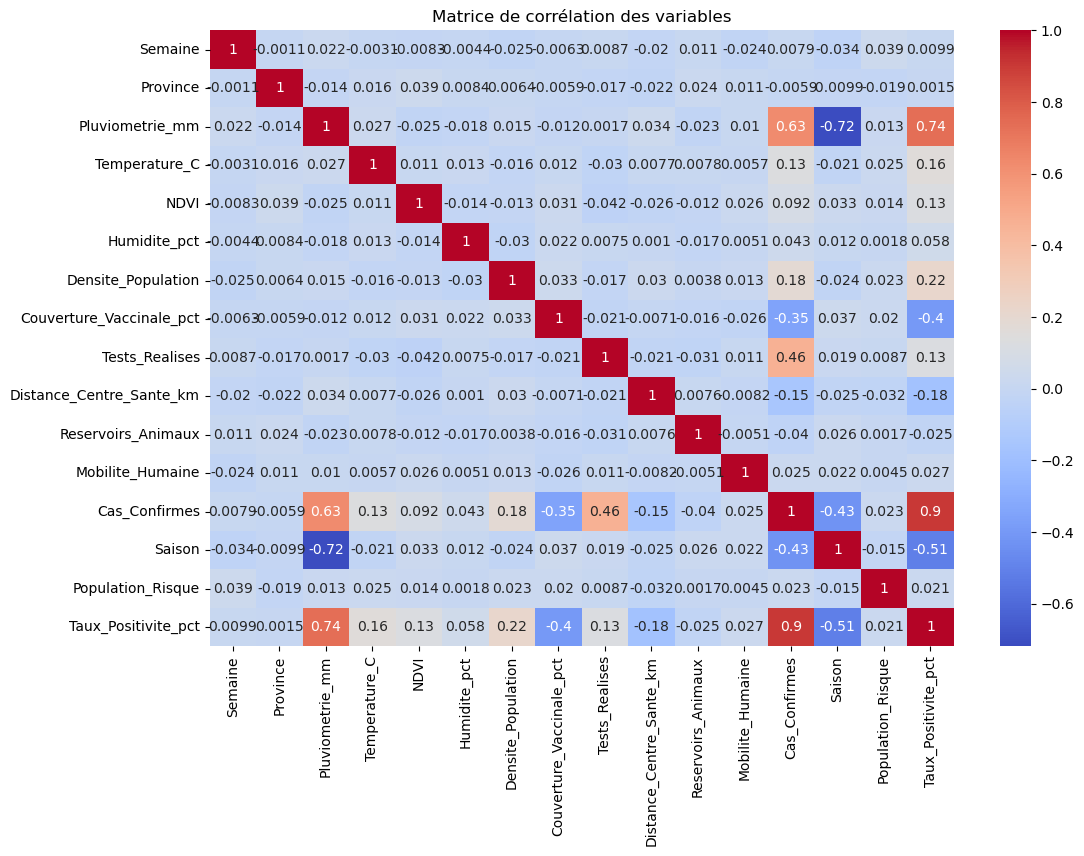

In [42]:
### Visualisation de la Corrélation
plt.figure(figsize=(12,8))

sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")

plt.title("Matrice de corrélation des variables")

plt.show("Cas_Confirmes")

In [ ]:
### Interpretation de la Matrice de Corrélation
*Cas_Confirmes vs Taux_Positivite_pct : 0.9  
Très forte corrélation positive. Plus le taux de positivité est élevé, plus on observe de cas confirmés. 

* Pluviometrie_mm vs Taux_Positivite_pct : 0.74  
 Forte corrélation positive. Les périodes de forte pluie semblent associées à une hausse du taux de positivité, 
peut-être parce que les conditions humides favorisent la transmission ou limitent l'accès aux soins.

Pluviometrie_mm vs Saison : -0.72  
 Forte corrélation négative. Certaines saisons sont caractérisées par moins de pluie, ce qui explique cette relation inverse.

* Saison vs Cas_Confirmes : -0.43  
 Corrélation négative modérée. Certaines saisons sont associées à moins de cas confirmés.

* Saison vs Taux_Positivite_pct : -0.51  
 Corrélation négative modérée. Cela suggère que la saisonnalité influence la dynamique de l’épidémie.

SyntaxError: invalid character '’' (U+2019) (1518201126.py, line 7)

In [52]:
bo = model_LRM.intercept_
bo

np.float64(-75.1078542204079)

In [ ]:
### Interprétation du Model
Le b_0 = -75,11 :Est le point de départ théorique du modèle. Si toutes tes variables 
d'entrée ($X$) valaient zéro, le modèle prédirait une valeur de $-75,11$ pour ma variable cible.
NB. L'intercept à lui seul ne donne pas la précision du modèle et pour la prise de la décision.


In [57]:
from sklearn.metrics import r2_score, mean_squared_error
### . Performances du Modèle
#  Evaluation des performances du jeu de test (x_test, y_test)
# 1. Faire des prédictions sur les données de test
y_pred = model_LRM.predict(x_test)

# 2. Calculer le score R² (pourcentage de variance expliquée, idéalement proche de 1)
r2 = r2_score(y_test, y_pred)
print("Score R² :", r2)

Score R² : 0.9325384824006936


In [ ]:
### Interpretation du Model à partir du R²
le score R^2 est de 0,9325 (soit environ 93,25 %) et indique que le modèle est particulièrement performant et l'incertitude est tellement minime.

In [53]:
coef = model_LRM.coef_
coef

array([-3.16845225e-04, -2.83778922e-02, -1.80488699e-02,  1.05438464e-01,
       -2.21798813e+00, -8.73363652e-02, -8.47406359e-03,  4.92615146e-02,
        2.74482028e-01,  5.81411099e-02, -1.13281972e+00, -4.55043147e-02,
        9.46913539e-03,  4.86889887e-05,  3.07991766e+00])

In [54]:
y_pred = model_LRM.predict(x_test)
y_pred

array([ 8.73368859e+01,  3.47087478e+01,  2.28118073e+02,  4.19711160e+01,
        3.41833352e+01,  1.71760394e+02,  1.35326376e+02,  1.23841300e+02,
        4.75739113e+01, -1.27505089e+01,  9.40719722e+01,  9.12840456e+01,
       -2.23141241e+01,  1.94671004e+02,  4.56506917e+01,  1.40088255e+01,
        2.38993258e+02,  1.21361638e+02,  2.28230903e+02,  4.26608830e+01,
        2.35186195e+02, -3.52142785e+00,  6.37741579e+01,  8.92348604e+01,
        1.64957364e+02,  4.73160497e+01,  1.10797257e+02, -7.29018384e+00,
        2.68077762e+01,  2.78151854e+01,  1.18982990e+02,  1.46170292e+01,
       -1.58359275e+01,  8.66373545e+01,  2.01728451e+02,  1.39330890e+02,
        3.32546342e+01,  1.20780516e+02,  1.84495829e+02,  4.02730586e+00,
        1.06513524e+02, -1.33888224e+01,  1.65340447e+01, -1.28752810e+01,
       -1.83860867e+01,  1.89555811e+01,  1.29311433e+02,  3.10602016e+01,
        4.47071081e+01,  1.69617905e+02,  1.04444627e+02,  4.49359484e+01,
        1.58293004e+02,  

In [56]:
import math
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Calcule d'abord les prédictions
y_pred = model_LRM.predict(x_test)

# Affichage des métriques de performance
print("MSE  :", mean_squared_error(y_test, y_pred))
print("MAE  :", mean_absolute_error(y_test, y_pred))
print("RMSE :", math.sqrt(mean_squared_error(y_test, y_pred)))
print("R²   :", r2_score(y_test, y_pred))

MSE  : 361.3430246583179
MAE  : 12.472482851410987
RMSE : 19.00902482133994
R²   : 0.9325384824006936


In [ ]:
### Interpretation du Modèle de Régression Linéaire Multiple
ce modèle  affiche d'excellentes performances globales, caractérisées par une grande précision de prédiction 
et une très bonne capacité à capturer la tendance de tes données.
le MAE = 12,47 — qui traduit une Erreur moyenne faible; d'oû les prédictions du modèle s'écartent de la réalité de seulement 12{,}47$ unités.
Pour le RMSE qui est de 19,01 et le MSE de 361,34; cela traduit une Bonne gestion des valeurs extrêmes
Le RMSE est un peu plus élevé que la MAE 19,01 contre 12,47, ce qui est normal : cette métrique pénalise plus lourdement les erreurs importantes. 
Cela indique la présence de quelques légers écarts ponctuels, mais rien d'alarmant au vu du score R^2.